Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from lifelines import KaplanMeierFitter
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack

plt.style.use("default")
sns.set(style="whitegrid")

#Load datasets from modelling notebook outputs
MI_finaldf = pd.read_csv("MI_finaldf.csv")
Finalmodel_df = pd.read_csv("Finalmodel_df.csv")

#quick check
print(MI_finaldf.shape)
print(Finalmodel_df.shape)

MI_finaldf.head()

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(16537, 24)
(16537, 11)


,subject_id,hadm_id,admittime,dischtime,admission_type,gender,age,curr_service,hospital_expire_flag,icd_code,...,admit_weekend,prior_mi,num_diagnoses_at_admission,procedure_count,drg_severity,drg_mortality,cardiac_proc_flag,next_admittime,days_to_readmit,readmit_30d
0,10000764,27897940,2132-10-14 23:31:00,2132-10-19 16:30:00,URGENT,M,86,MED,0,41071,...,Weekday,N,18,0.0,3.0,3.0,0,NaN,NaN,0
1,10000980,26913865,2189-06-27 07:38:00,2189-07-03 03:00:00,EW EMER.,F,73,MED,0,41071,...,Weekend,N,14,7.0,3.0,4.0,1,NaN,NaN,0
2,10001492,27463908,2136-09-23 18:02:00,2136-09-25 17:45:00,EW EMER.,F,71,MED,0,41071,...,Weekend,N,3,3.0,1.0,1.0,1,NaN,NaN,0
3,10002013,24760295,2160-07-10 19:33:00,2160-07-12 12:30:00,EW EMER.,F,53,CMED,0,41071,...,Weekday,N,14,2.0,3.0,3.0,1,NaN,NaN,0
4,10002155,23822395,2129-08-04 12:44:00,2129-08-18 16:53:00,EW EMER.,F,80,CMED,0,41011,...,Weekday,N,19,8.0,3.0,3.0,1,NaN,NaN,0


Baseline Summary Table (Table 1)

In [2]:
summary_table = pd.DataFrame()

#Age
summary_table.loc["Age (mean ± SD)", "Value"] = (
    f"{MI_finaldf['age'].mean():.1f} ± {MI_finaldf['age'].std():.1f}"
)

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5


In [3]:
#Gender
gender_counts = MI_finaldf['gender'].value_counts()
gender_pct = MI_finaldf['gender'].value_counts(normalize=True) * 100

summary_table.loc["Male, n (%)", "Value"] = (
    f"{gender_counts.get('M', 0)} ({gender_pct.get('M', 0):.1f}%)"
)
summary_table.loc["Female, n (%)", "Value"] = (
    f"{gender_counts.get('F', 0)} ({gender_pct.get('F', 0):.1f}%)"
)

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)


In [4]:
#Weekend admission
weekend_counts = MI_finaldf['admit_weekend'].value_counts()
weekend_pct = MI_finaldf['admit_weekend'].value_counts(normalize=True) * 100

summary_table.loc["Weekend admission, n (%)", "Value"] = (
    f"{weekend_counts.get('Weekend', 0)} ({weekend_pct.get('Weekend', 0):.1f}%)"
)

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)
"Weekend admission, n (%)",4765 (28.8%)


In [5]:
#Prior MI
prior_counts = MI_finaldf['prior_mi'].value_counts()
prior_pct = MI_finaldf['prior_mi'].value_counts(normalize=True) * 100

summary_table.loc["Prior MI, n (%)", "Value"] = (
    f"{prior_counts.get(1, 0)} ({prior_pct.get(1, 0):.1f}%)"
)

summary_table

C:\Users\User\AppData\Local\Temp\ipykernel_6104\1913372279.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{prior_counts.get(1, 0)} ({prior_pct.get(1, 0):.1f}%)"


,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)
"Weekend admission, n (%)",4765 (28.8%)
"Prior MI, n (%)",3385 (20.5%)


In [6]:
#Number of diagnoses at admission
summary_table.loc["No. diagnoses at admission (mean ± SD)", "Value"] = (
    f"{MI_finaldf['num_diagnoses_at_admission'].mean():.1f} ± "
    f"{MI_finaldf['num_diagnoses_at_admission'].std():.1f}"
)

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)
"Weekend admission, n (%)",4765 (28.8%)
"Prior MI, n (%)",3385 (20.5%)
No. diagnoses at admission (mean ± SD),17.5 ± 8.8


In [7]:
#Admission type
admission_counts = MI_finaldf['admission_type'].value_counts()
admission_pct = MI_finaldf['admission_type'].value_counts(normalize=True) * 100

for cat in admission_counts.index:
    summary_table.loc[f"Admission: {cat}, n (%)", "Value"] = (
        f"{admission_counts[cat]} ({admission_pct[cat]:.1f}%)"
    )

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)
"Weekend admission, n (%)",4765 (28.8%)
"Prior MI, n (%)",3385 (20.5%)
No. diagnoses at admission (mean ± SD),17.5 ± 8.8
"Admission: EW EMER., n (%)",6921 (41.9%)
"Admission: URGENT, n (%)",4402 (26.6%)
"Admission: OBSERVATION ADMIT, n (%)",3969 (24.0%)
"Admission: DIRECT EMER., n (%)",473 (2.9%)


In [8]:
#Curr_service (top 5)
service_counts = MI_finaldf['curr_service'].value_counts().head(5)
service_pct = MI_finaldf['curr_service'].value_counts(normalize=True).head(5) * 100

for svc in service_counts.index:
    summary_table.loc[f"Service: {svc}, n (%)", "Value"] = (
        f"{service_counts[svc]} ({service_pct[svc]:.1f}%)"
    )

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)
"Weekend admission, n (%)",4765 (28.8%)
"Prior MI, n (%)",3385 (20.5%)
No. diagnoses at admission (mean ± SD),17.5 ± 8.8
"Admission: EW EMER., n (%)",6921 (41.9%)
"Admission: URGENT, n (%)",4402 (26.6%)
"Admission: OBSERVATION ADMIT, n (%)",3969 (24.0%)
"Admission: DIRECT EMER., n (%)",473 (2.9%)


In [9]:
#LOS distribution
los_counts = MI_finaldf['los_cat'].value_counts()
los_pct = MI_finaldf['los_cat'].value_counts(normalize=True) * 100

for cat in los_counts.index:
    summary_table.loc[f"LOS {cat}, n (%)", "Value"] = (
        f"{los_counts[cat]} ({los_pct[cat]:.1f}%)"
    )

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)
"Weekend admission, n (%)",4765 (28.8%)
"Prior MI, n (%)",3385 (20.5%)
No. diagnoses at admission (mean ± SD),17.5 ± 8.8
"Admission: EW EMER., n (%)",6921 (41.9%)
"Admission: URGENT, n (%)",4402 (26.6%)
"Admission: OBSERVATION ADMIT, n (%)",3969 (24.0%)
"Admission: DIRECT EMER., n (%)",473 (2.9%)


In [10]:
#In-hospital mortality
mort_counts = MI_finaldf['hospital_expire_flag'].value_counts()
mort_pct = MI_finaldf['hospital_expire_flag'].value_counts(normalize=True) * 100

summary_table.loc["Mortality (1), n (%)", "Value"] = (
    f"{mort_counts.get(1, 0)} ({mort_pct.get(1, 0):.1f}%)"
)

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)
"Weekend admission, n (%)",4765 (28.8%)
"Prior MI, n (%)",3385 (20.5%)
No. diagnoses at admission (mean ± SD),17.5 ± 8.8
"Admission: EW EMER., n (%)",6921 (41.9%)
"Admission: URGENT, n (%)",4402 (26.6%)
"Admission: OBSERVATION ADMIT, n (%)",3969 (24.0%)
"Admission: DIRECT EMER., n (%)",473 (2.9%)


In [11]:
#30-day readmission
read_counts = MI_finaldf['readmit_30d'].value_counts()
read_pct = MI_finaldf['readmit_30d'].value_counts(normalize=True) * 100

summary_table.loc["Readmission (1), n (%)", "Value"] = (
    f"{read_counts.get(1, 0)} ({read_pct.get(1, 0):.1f}%)"
)

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)
"Weekend admission, n (%)",4765 (28.8%)
"Prior MI, n (%)",3385 (20.5%)
No. diagnoses at admission (mean ± SD),17.5 ± 8.8
"Admission: EW EMER., n (%)",6921 (41.9%)
"Admission: URGENT, n (%)",4402 (26.6%)
"Admission: OBSERVATION ADMIT, n (%)",3969 (24.0%)
"Admission: DIRECT EMER., n (%)",473 (2.9%)


In [12]:
#DRG severity > 2
sev_flag = (MI_finaldf['drg_severity'] > 2).sum()
sev_pct = (MI_finaldf['drg_severity'] > 2).mean() * 100

summary_table.loc["DRG severity > 2, n (%)", "Value"] = (
    f"{sev_flag} ({sev_pct:.1f}%)"
)

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)
"Weekend admission, n (%)",4765 (28.8%)
"Prior MI, n (%)",3385 (20.5%)
No. diagnoses at admission (mean ± SD),17.5 ± 8.8
"Admission: EW EMER., n (%)",6921 (41.9%)
"Admission: URGENT, n (%)",4402 (26.6%)
"Admission: OBSERVATION ADMIT, n (%)",3969 (24.0%)
"Admission: DIRECT EMER., n (%)",473 (2.9%)


In [13]:
#DRG Mortality > 2
sev_flag = (MI_finaldf['drg_mortality'] > 2).sum()
sev_pct = (MI_finaldf['drg_mortality'] > 2).mean() * 100

summary_table.loc["DRG mortality > 2, n (%)", "Value"] = (
    f"{sev_flag} ({sev_pct:.1f}%)"
)

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)
"Weekend admission, n (%)",4765 (28.8%)
"Prior MI, n (%)",3385 (20.5%)
No. diagnoses at admission (mean ± SD),17.5 ± 8.8
"Admission: EW EMER., n (%)",6921 (41.9%)
"Admission: URGENT, n (%)",4402 (26.6%)
"Admission: OBSERVATION ADMIT, n (%)",3969 (24.0%)
"Admission: DIRECT EMER., n (%)",473 (2.9%)


In [14]:
#Procedure count > 1
proc_flag = (MI_finaldf['procedure_count'] > 1).sum()
proc_pct = (MI_finaldf['procedure_count'] > 1).mean() * 100

summary_table.loc["Procedure count > 1, n (%)", "Value"] = (
    f"{proc_flag} ({proc_pct:.1f}%)"
)

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)
"Weekend admission, n (%)",4765 (28.8%)
"Prior MI, n (%)",3385 (20.5%)
No. diagnoses at admission (mean ± SD),17.5 ± 8.8
"Admission: EW EMER., n (%)",6921 (41.9%)
"Admission: URGENT, n (%)",4402 (26.6%)
"Admission: OBSERVATION ADMIT, n (%)",3969 (24.0%)
"Admission: DIRECT EMER., n (%)",473 (2.9%)


In [15]:
#High-risk cardiac procedure
card_flag = MI_finaldf['cardiac_proc_flag'].sum()
card_pct = MI_finaldf['cardiac_proc_flag'].mean() * 100

summary_table.loc["High-risk cardiac procedure, n (%)", "Value"] = (
    f"{card_flag} ({card_pct:.1f}%)"
)

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)
"Weekend admission, n (%)",4765 (28.8%)
"Prior MI, n (%)",3385 (20.5%)
No. diagnoses at admission (mean ± SD),17.5 ± 8.8
"Admission: EW EMER., n (%)",6921 (41.9%)
"Admission: URGENT, n (%)",4402 (26.6%)
"Admission: OBSERVATION ADMIT, n (%)",3969 (24.0%)
"Admission: DIRECT EMER., n (%)",473 (2.9%)


Class Distribution Plots

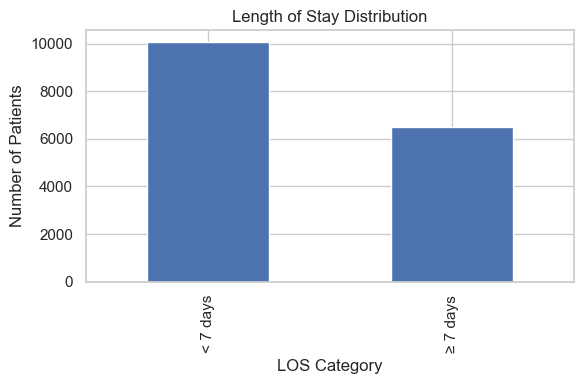

In [16]:
#LOS distribution
plt.figure(figsize=(6,4))

MI_finaldf['los_cat'].value_counts().plot(kind='bar')

plt.title("Length of Stay Distribution")
plt.xlabel("LOS Category")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

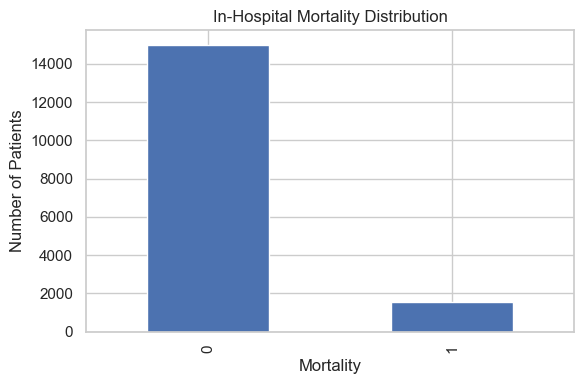

In [17]:
#Mortality distribution
plt.figure(figsize=(6,4))

MI_finaldf['hospital_expire_flag'].value_counts().plot(kind='bar')

plt.title("In-Hospital Mortality Distribution")
plt.xlabel("Mortality")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

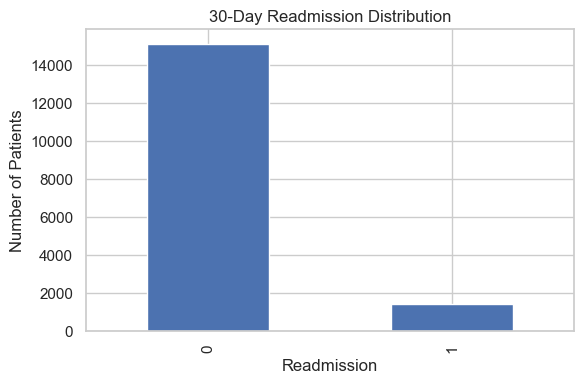

In [18]:
# ---------- Readmission distribution ----------
plt.figure(figsize=(6,4))

MI_finaldf['readmit_30d'].value_counts().plot(kind='bar')

plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmission")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

Variable distribution plots

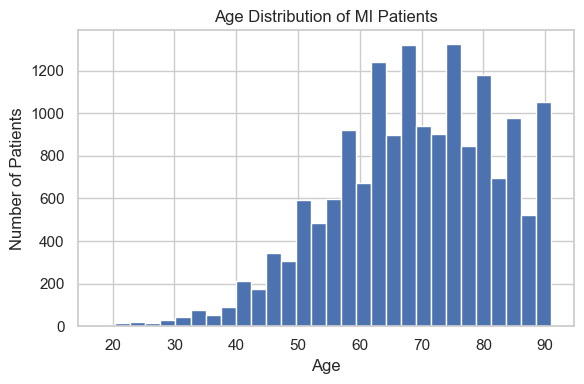

In [19]:
#Age distribution
plt.figure(figsize=(6,4))

plt.hist(MI_finaldf['age'], bins=30)

plt.title("Age Distribution of MI Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

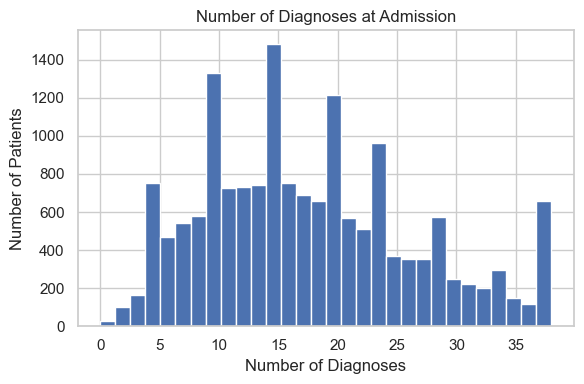

In [20]:
#Number of diagnoses distribution
plt.figure(figsize=(6,4))

plt.hist(MI_finaldf['num_diagnoses_at_admission'], bins=30)

plt.title("Number of Diagnoses at Admission")
plt.xlabel("Number of Diagnoses")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

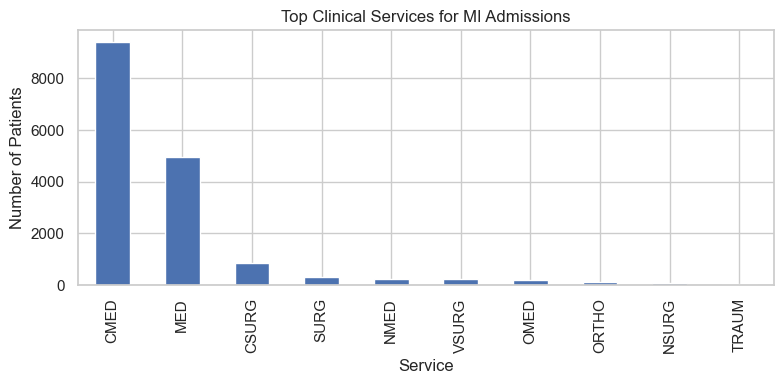

In [21]:
#Top services
plt.figure(figsize=(8,4))

MI_finaldf['curr_service'].value_counts().head(10).plot(kind='bar')

plt.title("Top Clinical Services for MI Admissions")
plt.xlabel("Service")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

5. Relationship Analysis

LOS vs Admission Type

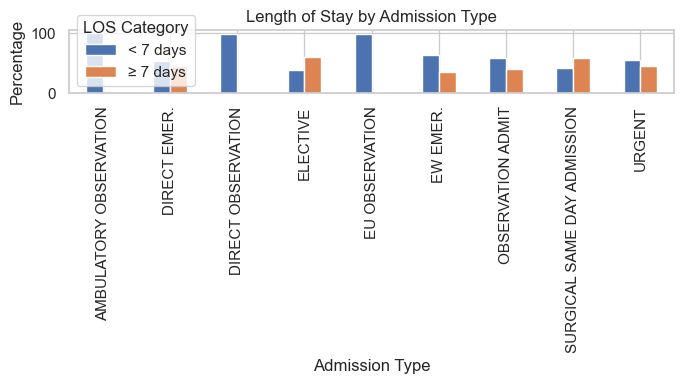

In [22]:
#LOS vs Admission Type

los_adm = pd.crosstab(MI_finaldf['admission_type'], MI_finaldf['los_cat'], normalize='index') * 100
los_adm.plot(kind='bar', figsize=(7, 4))

plt.title("Length of Stay by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Percentage")
plt.legend(title="LOS Category")

plt.tight_layout()
plt.show()

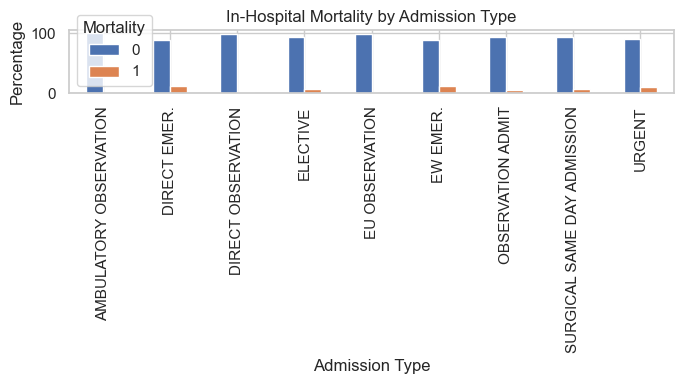

In [23]:
#Mortality vs Admission Type
mort_adm = pd.crosstab(MI_finaldf['admission_type'], MI_finaldf['hospital_expire_flag'], normalize='index') * 100
mort_adm.plot(kind='bar', figsize=(7, 4))

plt.title("In-Hospital Mortality by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Percentage")
plt.legend(title="Mortality")

plt.tight_layout()
plt.show()

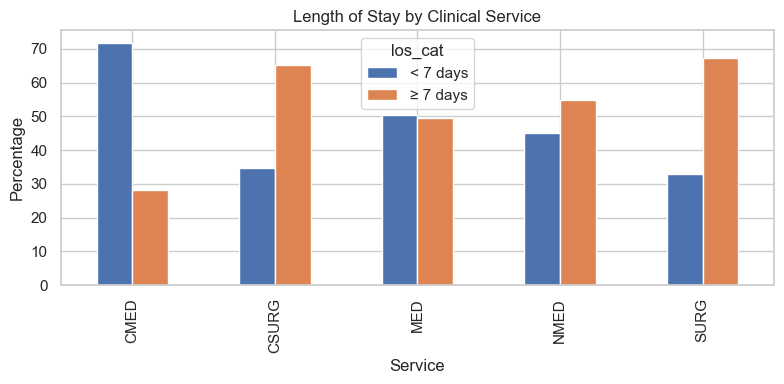

In [24]:
#LOS vs Clinical Service (Top 5)
top_services = MI_finaldf['curr_service'].value_counts().head(5).index
subset = MI_finaldf[MI_finaldf['curr_service'].isin(top_services)]

los_service = pd.crosstab(subset['curr_service'], subset['los_cat'], normalize='index') * 100
los_service.plot(kind='bar', figsize=(8, 4))

plt.title("Length of Stay by Clinical Service")
plt.xlabel("Service")
plt.ylabel("Percentage")

plt.tight_layout()
plt.show()

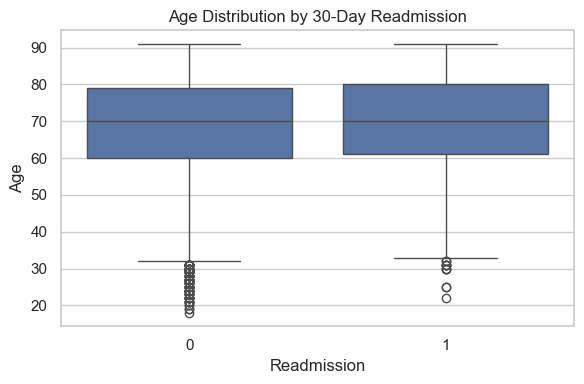

In [25]:
#Age distribution by 30-Day Readmission

plt.figure(figsize=(6, 4))
sns.boxplot(x=MI_finaldf['readmit_30d'], y=MI_finaldf['age'])

plt.title("Age Distribution by 30-Day Readmission")
plt.xlabel("Readmission")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

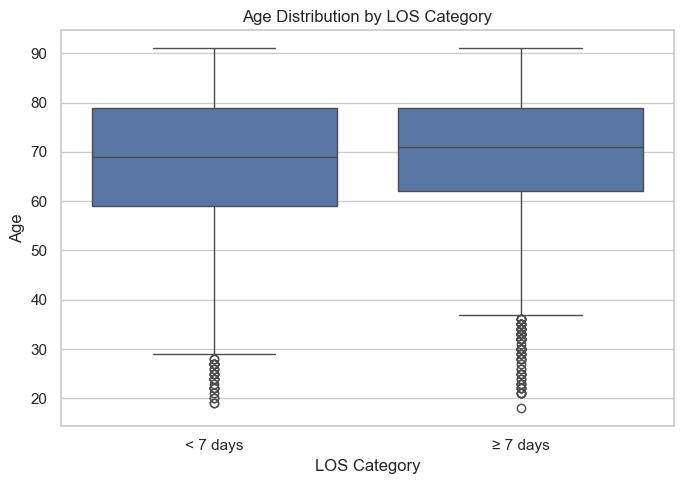

In [26]:
#Age distribution by LOS Category

plt.figure(figsize=(7, 5))
sns.boxplot(x=MI_finaldf['los_cat'], y=MI_finaldf['age'])

plt.title("Age Distribution by LOS Category")
plt.xlabel("LOS Category")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

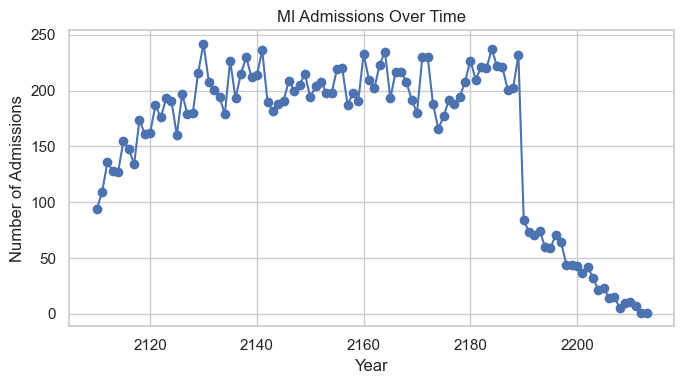

In [27]:
#MI admissions over time
MI_finaldf['admittime'] = pd.to_datetime(MI_finaldf['admittime'])
MI_finaldf['year'] = MI_finaldf['admittime'].dt.year
year_counts = MI_finaldf['year'].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.plot(year_counts.index, year_counts.values, marker='o')

plt.title("MI Admissions Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Admissions")

plt.tight_layout()
plt.show()

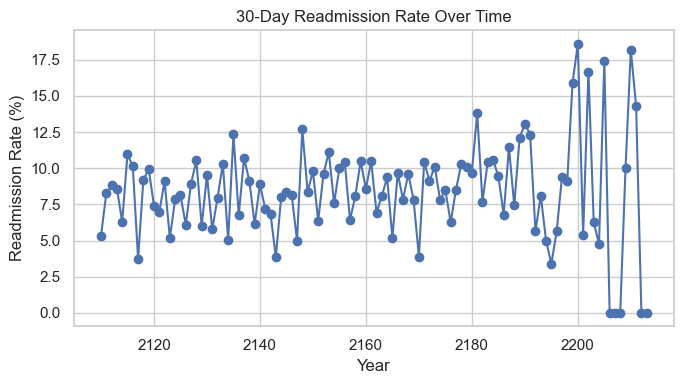

In [28]:
#30-Day Readmission Rate Over Time
readm_year = MI_finaldf.groupby('year')['readmit_30d'].mean() * 100

plt.figure(figsize=(7, 4))
plt.plot(readm_year.index, readm_year.values, marker='o')

plt.title("30-Day Readmission Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Readmission Rate (%)")

plt.tight_layout()
plt.show()

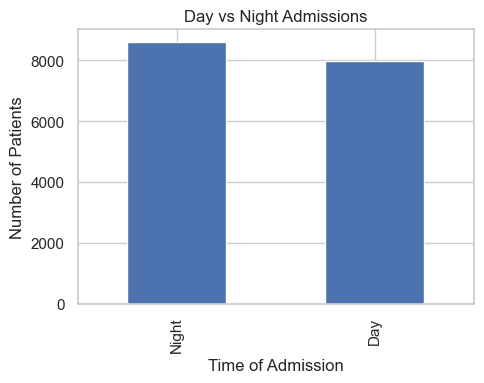

In [29]:
#Day vs Night Admissions
MI_finaldf['hour'] = MI_finaldf['admittime'].dt.hour
MI_finaldf['day_night'] = np.where(MI_finaldf['hour'].between(7, 18), "Day", "Night")

daynight_counts = MI_finaldf['day_night'].value_counts()
daynight_counts.plot(kind='bar', figsize=(5, 4))

plt.title("Day vs Night Admissions")
plt.xlabel("Time of Admission")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

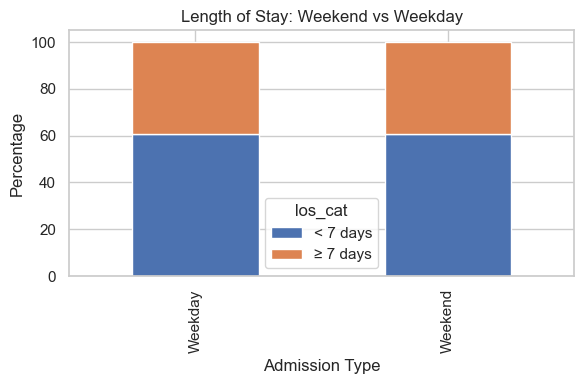

In [30]:
#LOS: Weekend vs Weekday
los_weekend = pd.crosstab(
    MI_finaldf['admit_weekend'],
    MI_finaldf['los_cat'],
    normalize='index'
) * 100

los_weekend.plot(kind='bar', stacked=True, figsize=(6, 4))

plt.title("Length of Stay: Weekend vs Weekday")
plt.xlabel("Admission Type")
plt.ylabel("Percentage")

plt.tight_layout()
plt.show()

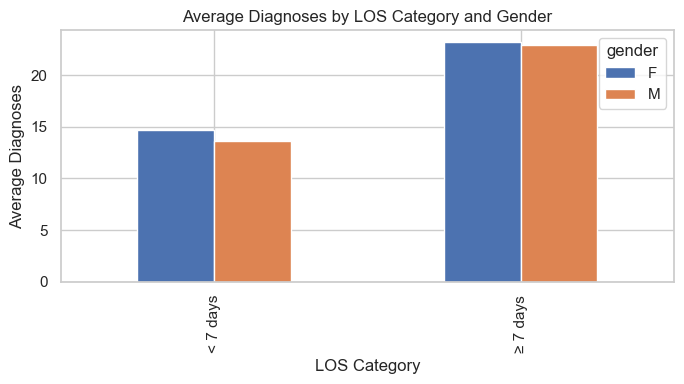

In [31]:
#Average Diagnoses by LOS Category and Gender
diag_los_gender = MI_finaldf.groupby(
    ['los_cat', 'gender']
)['num_diagnoses_at_admission'].mean().unstack()

diag_los_gender.plot(kind='bar', figsize=(7, 4))
plt.title("Average Diagnoses by LOS Category and Gender")
plt.xlabel("LOS Category")
plt.ylabel("Average Diagnoses")
plt.tight_layout()
plt.show()

6. Survival / Kaplan-Meier Curves

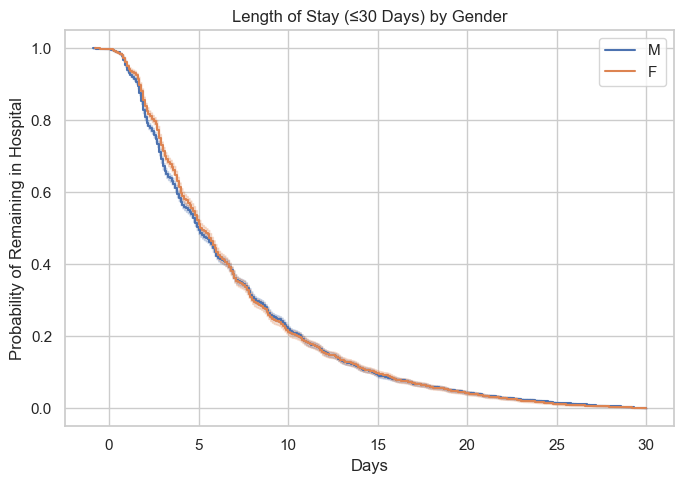

In [32]:
#Kaplan-Meier: LOS by Gender (trimmed to ≤30 days)
kmf = KaplanMeierFitter()
plt.figure(figsize=(7, 5))

subset = MI_finaldf[MI_finaldf['los_days'] <= 30]

for gender in subset['gender'].unique():
    mask = subset['gender'] == gender
    kmf.fit(
        durations=subset.loc[mask, 'los_days'],
        event_observed=np.ones(mask.sum()),
        label=gender
    )
    kmf.plot()

plt.title("Length of Stay (≤30 Days) by Gender")
plt.xlabel("Days")
plt.ylabel("Probability of Remaining in Hospital")
plt.tight_layout()
plt.show()


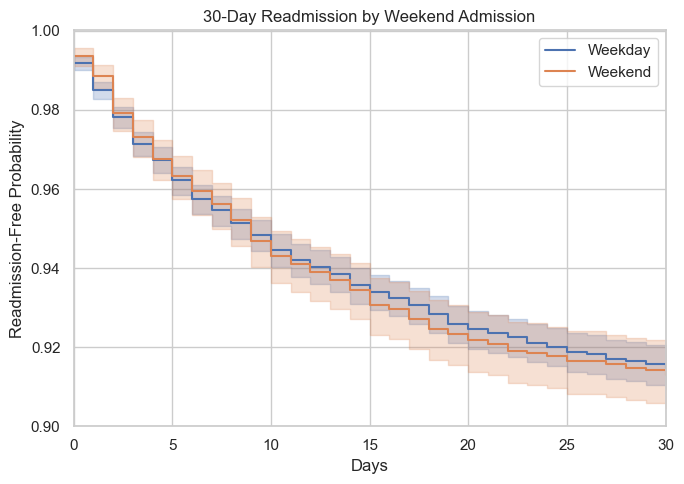

In [33]:
#Kaplan-Meier: 30-Day Readmission by Weekend Admission
kmf = KaplanMeierFitter()
plt.figure(figsize=(7, 5))

subset = MI_finaldf.copy()
subset['time_readmit'] = subset['days_to_readmit'].fillna(30).clip(upper=30)
subset['event'] = subset['readmit_30d']

for weekend in subset['admit_weekend'].unique():
    mask = subset['admit_weekend'] == weekend
    kmf.fit(
        durations=subset.loc[mask, 'time_readmit'],
        event_observed=subset.loc[mask, 'event'],
        label=f"{weekend}"
    )
    kmf.plot()

plt.title("30-Day Readmission by Weekend Admission")
plt.xlabel("Days")
plt.ylabel("Readmission-Free Probability")
plt.xlim(0, 30)
plt.tight_layout()
plt.show()

7. Stratified Outcome Analysis

C:\Users\User\AppData\Local\Temp\ipykernel_6104\4099463267.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mort_age_gender = subset.groupby(['age_group', 'gender'])['hospital_expire_flag'].mean().unstack()


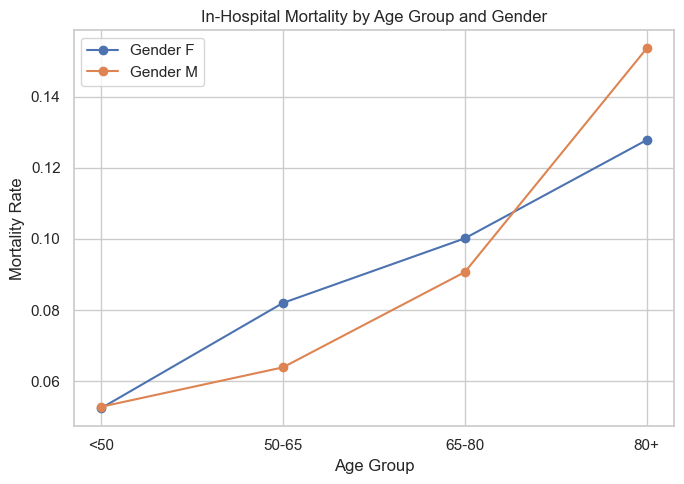

In [34]:
#Mortality by Age Group and Gender
subset = MI_finaldf.copy()
subset['age_group'] = pd.cut(
    subset['age'],
    bins=[0, 50, 65, 80, 120],
    labels=['<50', '50-65', '65-80', '80+']
)

mort_age_gender = subset.groupby(['age_group', 'gender'])['hospital_expire_flag'].mean().unstack()

plt.figure(figsize=(7, 5))
for gender in mort_age_gender.columns:
    plt.plot(mort_age_gender.index, mort_age_gender[gender], marker='o', label=f"Gender {gender}")
plt.title("In-Hospital Mortality by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Mortality Rate")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_6104\3284152381.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  read_age_gender = subset.groupby(['age_group', 'gender'])['readmit_30d'].mean().unstack()


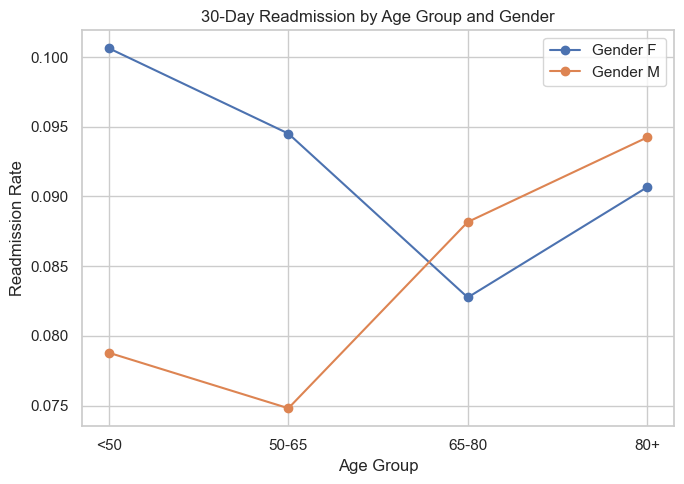

In [35]:
#Readmission by Age Group and Gender
subset = MI_finaldf.copy()
subset['age_group'] = pd.cut(
    subset['age'],
    bins=[0, 50, 65, 80, 120],
    labels=['<50', '50-65', '65-80', '80+']
)

read_age_gender = subset.groupby(['age_group', 'gender'])['readmit_30d'].mean().unstack()

plt.figure(figsize=(7, 5))
for gender in read_age_gender.columns:
    plt.plot(read_age_gender.index, read_age_gender[gender], marker='o', label=f"Gender {gender}")
plt.title("30-Day Readmission by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate")
plt.legend()
plt.tight_layout()
plt.show()

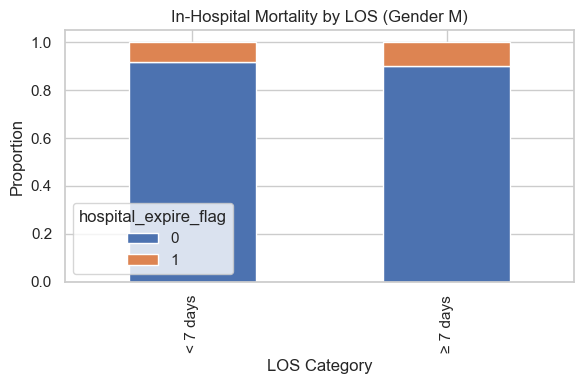

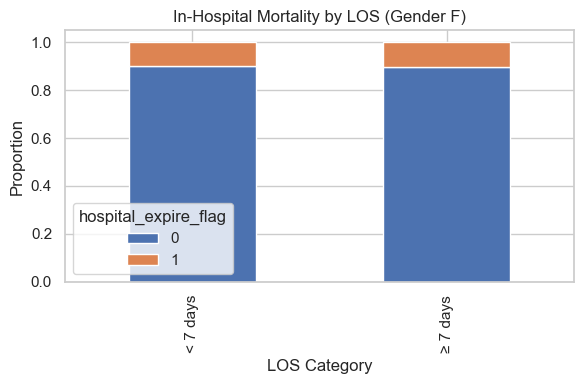

In [36]:
#In-Hospital Mortality by LOS — by Gender
for gender in MI_finaldf['gender'].unique():
    subset = MI_finaldf[MI_finaldf['gender'] == gender]
    los_mort = pd.crosstab(subset['los_cat'], subset['hospital_expire_flag'], normalize='index')
    los_mort.plot(kind='bar', stacked=True, figsize=(6, 4))
    plt.title(f"In-Hospital Mortality by LOS (Gender {gender})")
    plt.xlabel("LOS Category")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()

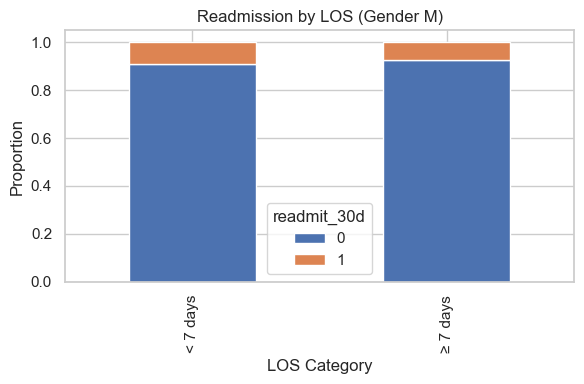

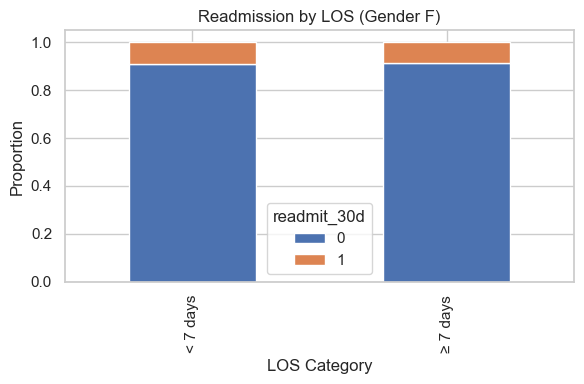

In [37]:
#Readmission by LOS — by Gender
for gender in MI_finaldf['gender'].unique():
    subset = MI_finaldf[MI_finaldf['gender'] == gender]
    los_read = pd.crosstab(subset['los_cat'], subset['readmit_30d'], normalize='index')
    los_read.plot(kind='bar', stacked=True, figsize=(6, 4))
    plt.title(f"Readmission by LOS (Gender {gender})")
    plt.xlabel("LOS Category")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()

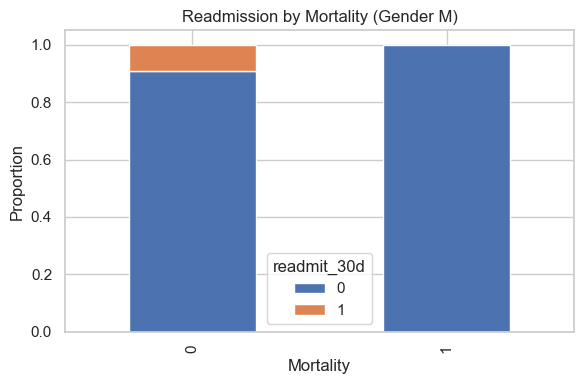

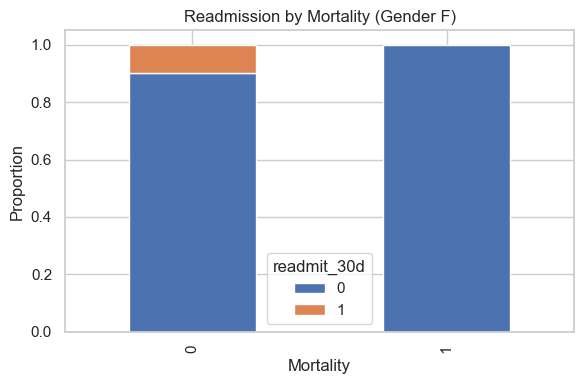

In [38]:
#Readmission by Mortality — by Gender
for gender in MI_finaldf['gender'].unique():
    subset = MI_finaldf[MI_finaldf['gender'] == gender]
    mort_read = pd.crosstab(subset['hospital_expire_flag'], subset['readmit_30d'], normalize='index')
    mort_read.plot(kind='bar', stacked=True, figsize=(6, 4))
    plt.title(f"Readmission by Mortality (Gender {gender})")
    plt.xlabel("Mortality")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()

8. Model Setup — Load Saved Models, Encoders & Recreate Test Sets
#same split as final notebook

In [39]:
# Load saved models and encoder for LOS
final_los_model = joblib.load("Final_LOS_Model.pkl")
encoder_los = joblib.load("LOS_Encoder.pkl")

print("Models and encoders loaded successfully.")

Models and encoders loaded successfully.


In [40]:
# Recreate patient-level split (must match main notebook exactly)
train_patients, test_patients = train_test_split(
    Finalmodel_df["subject_id"].unique(),
    test_size=0.2,
    random_state=42
)

print("Train patients:", len(train_patients))
print("Test patients:", len(test_patients))
print("Patient overlap:", len(set(train_patients) & set(test_patients)))

Train patients: 10521
Test patients: 2631
Patient overlap: 0


In [41]:
# --- LOS test set ---
cat_cols_los = ["gender", "admission_type", "curr_service", "admit_weekend", "prior_mi"]
num_cols_los = ["age", "num_diagnoses_at_admission"]

test_df_los = Finalmodel_df[Finalmodel_df["subject_id"].isin(test_patients)].copy()
X_test_los = test_df_los.drop(columns=["los_cat", "readmit_30d", "hospital_expire_flag", "subject_id"])
y_test_los = test_df_los["los_cat"]
y_test_los_bin = (y_test_los == "≥ 7 days").astype(int)

X_test_cat_los = encoder_los.transform(X_test_los[cat_cols_los])
X_test_num_los = X_test_los[num_cols_los].astype(float).values
X_test_enc_los = hstack([X_test_cat_los, X_test_num_los])

# Feature names for SHAP
los_feature_names = list(encoder_los.get_feature_names_out(cat_cols_los)) + num_cols_los

print("LOS test set ready. Shape:", X_test_enc_los.shape)

LOS test set ready. Shape: (3281, 36)


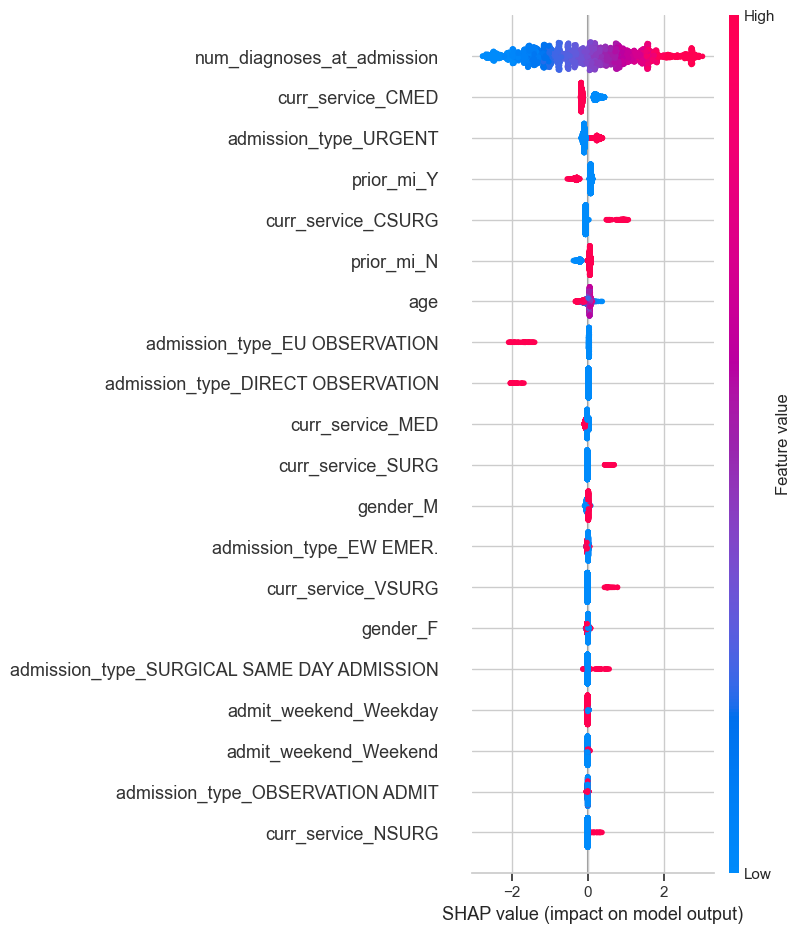

In [42]:
X_test_los_dense = pd.DataFrame(
    X_test_enc_los.toarray(),
    columns=los_feature_names
)

explainer_los = shap.TreeExplainer(final_los_model)
shap_values_los = explainer_los.shap_values(X_test_los_dense)

shap.summary_plot(shap_values_los, X_test_los_dense, feature_names=los_feature_names)